In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

from sklearn.decomposition import PCA

import numpy as np

from scipy.stats import spearmanr

import matplotlib.pyplot as plt

from matplotlib.patches import Wedge

from adjustText import adjust_text

from skbio import DistanceMatrix
from skbio.stats.distance import mantel

from umap import UMAP

import pickle

import torch

import torch.nn.functional as F

c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2264.71it/s]


In [2]:

# carico i dataset
synonym_df = pd.read_csv("synonym_pairs_final.csv")
antonym_df = pd.read_csv("antonym_pairs_final.csv")
random_df = pd.read_csv("random_pairs_final.csv")


#codice da eseguire per avere la matrice di embedding del vocabolario delle analogie (ES 3)
data = torch.load("sbert_vocab_100k.pt")

vocab_100k = data["vocab"]
embeddings_matrix_100k = data["embeddings"]




In [3]:
#Estrazione delle PCA (50,10,2 D)
#creo una lista contenente  elementi del dizionario
words = list(vocab_100k)
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix_100k = embeddings_matrix_100k.numpy()

print(embedding_matrix_100k.shape)

(100000, 384)


In [ ]:
#CODICE DA NON ESEGUIRE
# Estrazione delle PCA (50,10,2 D) Solo sui dati delle parole
#converto dizionario di embedding in una matrice Numpy
#creo una lista contenente le chiavi del dizionario
#words = list(embeddings.keys())
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
#embedding_matrix = np.vstack([
    #embeddings[word].numpy()
    #for word in words
#])

#print(embedding_matrix.shape)

(638, 384)


In [4]:
#PCA 50 D
pca_50 = PCA(n_components=50, random_state=42)
pca_50_embedding_100k = pca_50.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding_100k.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 50 D: (100000, 50)
Varianza spiegata totale: 0.4404861


In [5]:
#PCA 10 D
pca_10 = PCA(n_components=10, random_state=42)
pca_10_embedding_100k = pca_10.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding_100k.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (100000, 10)
Varianza spiegata totale: 0.14864291


In [6]:
#PCA 2 D
pca_2 = PCA(n_components=2, random_state=42)
pca_2_embedding_100k = pca_2.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding_100k.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (100000, 2)
Varianza spiegata totale: 0.044483498


In [39]:
#riassunto:
print("Varianza spiegata totale di PCA 50 D:", pca_50.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

#per PCA 2: 

var_spiegata_2  = pca_2.explained_variance_ratio_
PCA_2_1 = (var_spiegata_2[0] * 100).round(4)
PCA_2_2 = (var_spiegata_2[1] * 100).round(4)
varianza_totale = (var_spiegata_2[:2].sum() * 100).round(4)

print(varianza_totale)

Varianza spiegata totale di PCA 50 D: 0.4404861
Varianza spiegata totale di PCA 10 D: 0.14864291
Varianza spiegata totale di PCA 2 D: 0.044483498
4.4484


In [7]:
#codice da eseguire per avere gli embedding modello originale delle parole dei tre dataset

import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [15]:
# creo un unico set con tutte le parole presenti nei tre esperimenti

all_words = set()

# sinonimi
all_words.update(synonym_df["word"])
all_words.update(synonym_df["synonym"])

# contrari
all_words.update(antonym_df["word"])
all_words.update(antonym_df["antonym"])

# random
all_words.update(random_df["word"])
all_words.update(random_df["random"])

print("Numero totale parole:", len(all_words))

#la trasformo in lista
all_words = sorted(all_words)

print("Numero totale parole:", len(all_words))

Numero totale parole: 638
Numero totale parole: 638


In [16]:
#proietto i 638 embedding negli spazi ridotti:
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix_2 = np.vstack([
    embeddings[word].numpy()
    for word in all_words
])

In [17]:
#proietto 638 valori nello spazio PCA

pca_50_embedding = pca_50.transform(embedding_matrix_2)
pca_10_embedding = pca_10.transform(embedding_matrix_2)
pca_2_embedding = pca_2.transform(embedding_matrix_2)

In [18]:
#ricreo dizionari di embedding

diz_embeddings_pca_50 = {
    word: pca_50_embedding [i]
    for i, word in enumerate(all_words)
}

diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(all_words)
}

diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(all_words)
}

In [19]:
#rifaccio primo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = diz_embedding[w1]
        emb2 = diz_embedding[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [20]:
#funzione per sinonimi

syn_df_50D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_50
)

syn_df_10D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_10
)

syn_df_2D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_2
)

print("Sinonimi PCA 50 D:\n" ,syn_df_50D.head() )
print("\n")
print("Sinonimi PCA 10 D:\n", syn_df_10D.head())
print("\n")
print("Sinonimi PCA 2 D:\n",syn_df_2D.head())

Sinonimi PCA 50 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.454553
1   ghastly      macabre  synonym           0.023829
2     dodgy        dicey  synonym           0.322540
3  biweekly  fortnightly  synonym           0.174226
4   pouring      gushing  synonym           0.579199


Sinonimi PCA 10 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.519024
1   ghastly      macabre  synonym          -0.060393
2     dodgy        dicey  synonym           0.530991
3  biweekly  fortnightly  synonym           0.468655
4   pouring      gushing  synonym           0.681332


Sinonimi PCA 2 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.990574
1   ghastly      macabre  synonym          -0.958545
2     dodgy        dicey  synonym           0.990365
3  biweekly  fortnightly  synonym           0.524089
4   pouring      gushing  synonym   

In [21]:
#funzione per contrari
ant_df_50D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_50
)

ant_df_10D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_10
)

ant_df_2D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_2
)

print("Contrari PCA 50 D:\n" ,ant_df_50D.head() )
print("\n")
print("Contrari PCA 10 D:\n", ant_df_10D.head())
print("\n")
print("Contrari PCA 2 D:\n",ant_df_2D.head())

Contrari PCA 50 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.818503
1  centralized  decentralized  antonym           0.637625
2   reasonable   unreasonable  antonym           0.817817
3       simple        complex  antonym           0.491052
4      legible      illegible  antonym           0.561258


Contrari PCA 10 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.871568
1  centralized  decentralized  antonym           0.742139
2   reasonable   unreasonable  antonym           0.835135
3       simple        complex  antonym           0.633434
4      legible      illegible  antonym           0.817885


Contrari PCA 2 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.956120
1  centralized  decentralized  antonym           0.986685
2   reasonable   unreasonable  antonym           0.960841
3       s

In [22]:
#Random
rand_df_50D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_50
)

rand_df_10D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_10
)

rand_df_2D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_2
)

print("Random PCA 50 D:\n" ,rand_df_50D.head())
print("\n")
print("Random PCA 10 D:\n" ,rand_df_10D.head())
print("\n")
print("Random PCA 2 D:\n" ,rand_df_2D.head())

Random PCA 50 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.072674
1  unpalatable  melancholic   random           0.359557
2     obliging     definite   random          -0.110825
3    punishing  recombinant   random           0.105927
4      opposed        ionic   random           0.018098


Random PCA 10 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.415604
1  unpalatable  melancholic   random           0.581757
2     obliging     definite   random           0.530836
3    punishing  recombinant   random           0.349327
4      opposed        ionic   random          -0.087462


Random PCA 2 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.475553
1  unpalatable  melancholic   random           0.791541
2     obliging     definite   random           0.986512
3    punishing  recombinant   random           

In [23]:
#salvo i risultati
syn_df_50D.to_csv(
    "results_synonyms_similarity_PCA50.csv",
    index=False
)

syn_df_10D.to_csv(
    "results_synonyms_similarity_PCA10.csv",
    index=False
)

syn_df_2D.to_csv(
    "results_synonyms_similarity_PCA2.csv",
    index=False
)

ant_df_50D.to_csv(
    "results_antonyms_similarity_PCA50.csv",
    index=False
)

ant_df_10D.to_csv(
    "results_antonyms_similarity_PCA10.csv",
    index=False
)

ant_df_2D.to_csv(
    "results_antonyms_similarity_PCA2.csv",
    index=False
)

rand_df_50D.to_csv(
    "results_random_similarity_PCA50.csv",
    index=False
)

rand_df_10D.to_csv(
    "results_random_similarity_PCA10.csv",
    index=False
)

rand_df_2D.to_csv(
    "results_random_similarity_PCA2.csv",
    index=False
)

In [24]:
#per caricare dataset con cosine similarity

syn_df_50D = pd.read_csv("results_synonyms_similarity_PCA50.csv")
syn_df_10D = pd.read_csv("results_synonyms_similarity_PCA10.csv")
syn_df_2D = pd.read_csv("results_synonyms_similarity_PCA2.csv")
ant_df_50D = pd.read_csv("results_antonyms_similarity_PCA50.csv")
ant_df_10D = pd.read_csv("results_antonyms_similarity_PCA10.csv")
ant_df_2D = pd.read_csv("results_antonyms_similarity_PCA2.csv")
rand_df_50D = pd.read_csv("results_random_similarity_PCA50.csv")
rand_df_10D = pd.read_csv("results_random_similarity_PCA10.csv")
rand_df_2D = pd.read_csv("results_random_similarity_PCA2.csv")

In [25]:
#Statistiche descrittive
print("SINONIMI")
print("Sinonimi per embedding a 50 dimensioni:\n")
print(syn_df_50D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 10 dimensioni:\n")
print(syn_df_10D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 2 dimensioni:\n")
print(syn_df_2D["cosine_similarity"].describe().round(3))
print("\nCONTRARI")
print("Contrari per embedding a 50 dimensioni:\n")
print(ant_df_50D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 10 dimensioni:\n")
print(ant_df_10D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 2 dimensioni:\n")
print(ant_df_2D["cosine_similarity"].describe().round(3))
print("\nRANDOM")
print("Random per embedding a 50 dimensioni:\n")
print(rand_df_50D["cosine_similarity"].describe().round(3))
print("Random per embedding a 10 dimensioni:\n")
print(rand_df_10D["cosine_similarity"].describe().round(3))
print("Random per embedding a 2 dimensioni:\n")
print(rand_df_2D["cosine_similarity"].describe().round(3))

SINONIMI
Sinonimi per embedding a 50 dimensioni:

count    111.000
mean       0.369
std        0.227
min       -0.153
25%        0.186
50%        0.383
75%        0.535
max        0.836
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 10 dimensioni:

count    111.000
mean       0.505
std        0.327
min       -0.482
25%        0.370
50%        0.540
75%        0.778
max        0.957
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 2 dimensioni:

count    111.000
mean       0.593
std        0.614
min       -1.000
25%        0.506
50%        0.906
75%        0.980
max        1.000
Name: cosine_similarity, dtype: float64

CONTRARI
Contrari per embedding a 50 dimensioni:

count    111.000
mean       0.515
std        0.235
min       -0.059
25%        0.364
50%        0.560
75%        0.683
max        0.922
Name: cosine_similarity, dtype: float64
Contrari per embedding a 10 dimensioni:

count    111.000
mean       0.656
std        0.267
min       -0.199
25%  

C:\Users\marco\AppData\Local\Temp\ipykernel_9580\3574747906.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


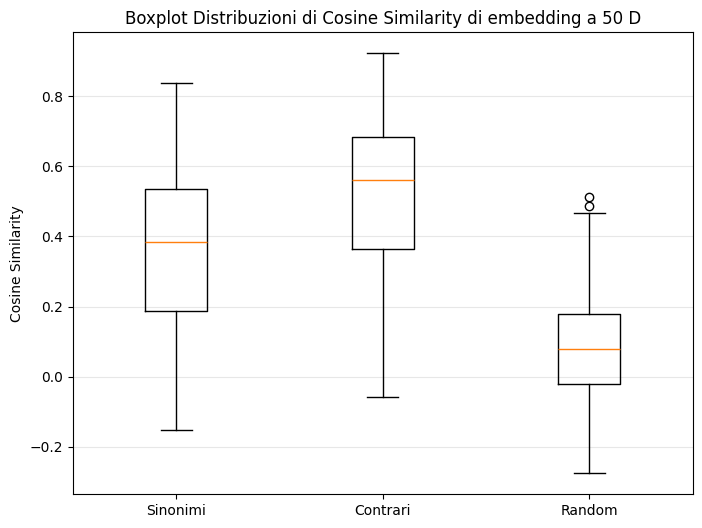

In [26]:
#BOX-Plot PCA 50 D:
#confronto tra le distribuzioni: box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_50D["cosine_similarity"],
        ant_df_50D["cosine_similarity"],
        rand_df_50D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 50 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_50D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_9580\3089064329.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


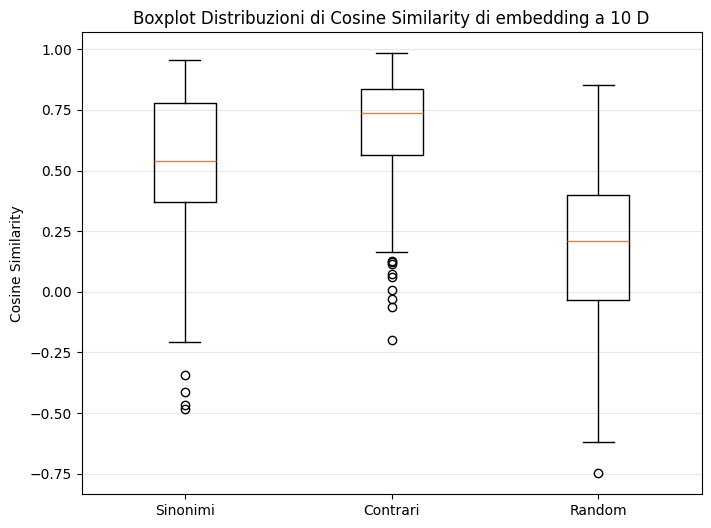

In [27]:
#BOX-Plot PCA 10 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_10D["cosine_similarity"],
        ant_df_10D["cosine_similarity"],
        rand_df_10D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 10 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_10D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_9580\1874310280.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


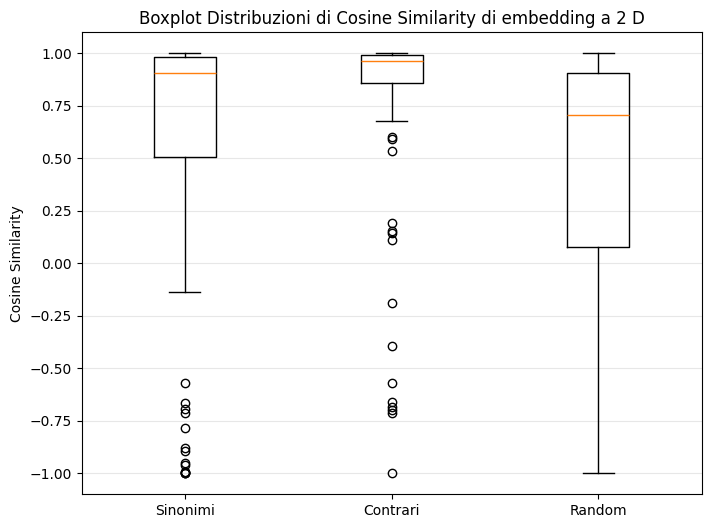

In [28]:
#BOX-Plot PCA 2 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_2D["cosine_similarity"],
        ant_df_2D["cosine_similarity"],
        rand_df_2D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 2 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
#Valutazione se usare Anova o meno 1:
#ci sono evidenze statistiche contro la normalità di distribuzione delle distanze?
#Shapiro-Wilk test


def Shapiro_test (syn_df, ant_df, rand_df):
    print("Shapiro-Wilk test\n")

    for nome, df in [
        ("Sinonimi", syn_df),
        ("Contrari", ant_df),
        ("Random", rand_df)
    ]:

        statistic, p_value = shapiro(df["cosine_similarity"])

        print(f"{nome}")
        print(f"W = {statistic:.4f}")
        print(f"p-value = {p_value:.4f}")

        if p_value > 0.05:
            print("La Distribuzione è compatibile con la distribuzione normale.\n")
        else:
            print("La distribuzione non è compatibile con la distribuzione normale.\n")
            
    return statistic, p_value

#PCA

print("PCA 50\n")
Shapiro_50D = Shapiro_test(syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Shapiro_10D = Shapiro_test(syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Shapiro_2D = Shapiro_test(syn_df_2D, ant_df_2D, rand_df_2D)

PCA 50

Shapiro-Wilk test

Sinonimi
W = 0.9854
p-value = 0.2706
La Distribuzione è compatibile con la distribuzione normale.

Contrari
W = 0.9668
p-value = 0.0072
La distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9858
p-value = 0.2933
La Distribuzione è compatibile con la distribuzione normale.


PCA 10

Shapiro-Wilk test

Sinonimi
W = 0.9138
p-value = 0.0000
La distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.8723
p-value = 0.0000
La distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9806
p-value = 0.1068
La Distribuzione è compatibile con la distribuzione normale.


PCA 2

Shapiro-Wilk test

Sinonimi
W = 0.6737
p-value = 0.0000
La distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.5150
p-value = 0.0000
La distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.7951
p-value = 0.0000
La distribuzione non è compatibile con la distribuzione normale.



In [30]:
#Test Lavene sull'omogeneità delle varianze tra le 3 distribuzioni (già dal boxplot potevamo ipotizzare che non lo fossero)
def Levene_test (syn_df, ant_df, rand_df):
    
    statistic, p_value = levene(
        syn_df["cosine_similarity"],
        ant_df["cosine_similarity"],
        rand_df["cosine_similarity"]
    )

    print("Levene test\n")

    print(f"Statistica = {statistic:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("Le varianze sono omogenee.")
    else:
        print("Le varianze NON sono omogenee.")
    return statistic, p_value

#PCA

Levene_50D = Levene_test(syn_df_50D, ant_df_50D, rand_df_50D)

Levene_10D = Levene_test(syn_df_10D, ant_df_10D, rand_df_10D)

Levene_2D = Levene_test(syn_df_2D, ant_df_2D, rand_df_2D)


Levene test

Statistica = 8.3426
p-value = 0.0003
Le varianze NON sono omogenee.
Levene test

Statistica = 3.4113
p-value = 0.0342
Le varianze NON sono omogenee.
Levene test

Statistica = 7.7985
p-value = 0.0005
Le varianze NON sono omogenee.


In [31]:
#si è scelto di usare un test non parametrico per definire se vi è una significativa differenza di distribuzione delle distanze:
#Test di Kruskall-Wallis
def kruskal_wallis_test(syn_df, ant_df, rand_df):
    
    risultati = stats.kruskal(syn_df["cosine_similarity"], ant_df["cosine_similarity"],  rand_df["cosine_similarity"])
    print(f"\n{risultati}")
    H = risultati.statistic.round(4)
    p_value = risultati.pvalue
    epsilon_quadrato = H / (len(syn_df["cosine_similarity"]) + len(ant_df["cosine_similarity"]) + len(rand_df["cosine_similarity"]) - 1)
    print(f"H = {H}")
    print(f"\np value = {p_value.round(4)}")
    print(f"\nEpsilon quadrato = {epsilon_quadrato.round(4)}")
    if p_value > 0.05:
        print("Non si riscontra alcuna differenza significativa nelle distribuzione delle distanze dei tre gruppi")
    else:
        print("\nAlmeno una distribuzione differisce significativamente dalle altre")
        
    return H, p_value, epsilon_quadrato

#PCA
print("PCA 50\n")
Kruskal_50D = kruskal_wallis_test(syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Kruskal_10D = kruskal_wallis_test(syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Kruskal_2D = kruskal_wallis_test(syn_df_2D, ant_df_2D, rand_df_2D)


PCA 50


KruskalResult(statistic=np.float64(141.59518703037065), pvalue=np.float64(1.7905885552594128e-31))
H = 141.5952

p value = 0.0

Epsilon quadrato = 0.4265

Almeno una distribuzione differisce significativamente dalle altre

PCA 10


KruskalResult(statistic=np.float64(106.99869703009381), pvalue=np.float64(5.828115561511013e-24))
H = 106.9987

p value = 0.0

Epsilon quadrato = 0.3223

Almeno una distribuzione differisce significativamente dalle altre

PCA 2


KruskalResult(statistic=np.float64(39.86459416205321), pvalue=np.float64(2.2055320138520982e-09))
H = 39.8646

p value = 0.0

Epsilon quadrato = 0.1201

Almeno una distribuzione differisce significativamente dalle altre


In [32]:
#test di Dunn con correzione di Holm per stabilire nello specifico quali distribuzioni differiscono
#unisco i dataset
def Dunn_test(syn_df, ant_df, rand_df):
    df_all = pd.concat([
        syn_df.assign(group="Synonyms"),
        ant_df.assign(group="Antonyms"),
        rand_df.assign(group="Random")
    ])
    
    dunn = sp.posthoc_dunn(
        df_all,
        val_col="cosine_similarity",
        group_col="group",
        p_adjust="holm"
    )
    
    print(f"{dunn.round(4)}\n")
    return dunn

#PCA
print("PCA 50\n")
Dunn_50D = Dunn_test(syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Dunn_10D = Dunn_test(syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Dunn_2D = Dunn_test(syn_df_2D, ant_df_2D, rand_df_2D)

PCA 50

          Antonyms  Random  Synonyms
Antonyms    1.0000     0.0    0.0002
Random      0.0000     1.0    0.0000
Synonyms    0.0002     0.0    1.0000


PCA 10

          Antonyms  Random  Synonyms
Antonyms    1.0000     0.0    0.0006
Random      0.0000     1.0    0.0000
Synonyms    0.0006     0.0    1.0000


PCA 2

          Antonyms  Random  Synonyms
Antonyms    1.0000  0.0000    0.0014
Random      0.0000  1.0000    0.0034
Synonyms    0.0014  0.0034    1.0000



In [33]:
#calcolo il delta per ogni coppia
from cliffs_delta import cliffs_delta

def Cliff_delta (syn_df, ant_df, rand_df):
    D_antvssyn = cliffs_delta( ant_df["cosine_similarity"], syn_df["cosine_similarity"])
    D, res = D_antvssyn
    print(f"\nContrari vs Sinonimi:{D,res}")

    D_antvsrand = cliffs_delta( ant_df["cosine_similarity"], rand_df["cosine_similarity"])
    D, res = D_antvsrand
    print(f"Contrari vs Random:{D,res}")

    D_synvsrand = cliffs_delta( syn_df["cosine_similarity"], rand_df["cosine_similarity"])
    D, res = D_synvsrand
    print(f"Sinonimi vs Random:{D,res}\n")
    
    return D_antvssyn, D_antvsrand, D_synvsrand


#PCA
print("PCA 50\n")
Cliff_50D = Cliff_delta (syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Cliff_10D = Cliff_delta (syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Cliff_2D = Cliff_delta (syn_df_2D, ant_df_2D, rand_df_2D)

PCA 50


Contrari vs Sinonimi:(0.357682006330655, 'medium')
Contrari vs Random:(0.8415713010307605, 'large')
Sinonimi vs Random:(0.6748640532424316, 'large')


PCA 10


Contrari vs Sinonimi:(0.301842382923464, 'small')
Contrari vs Random:(0.7527798068338609, 'large')
Sinonimi vs Random:(0.559451343235127, 'large')


PCA 2


Contrari vs Sinonimi:(0.2604496388280172, 'small')
Contrari vs Random:(0.49159970781592405, 'large')
Sinonimi vs Random:(0.22522522522522523, 'small')



In [34]:
#carico i dataset con cosine similarity degli embedding originali

orig_syn_df = pd.read_csv("results_synonyms_similarity.csv")
orig_ant_df = pd.read_csv("results_antonyms_similarity.csv")
orig_rand_df = pd.read_csv("results_random_similarity.csv")

In [35]:
#verificare la correlazione tra cosine similarity originale e quelle ridotte
def spearman (df_originale, df_pca):
    res = stats.spearmanr(df_originale["cosine_similarity"], df_pca["cosine_similarity"])
    print(f"Risultati:\n")
    print(f" rho = {res.statistic}")
    print(f"\np value = {res.pvalue.round(4)}\n")
    return res

#Confronti sinonimi
print("Sinonimi")
print("\noriginale vs 50\n")
syn_origvs50 = spearman (orig_syn_df, syn_df_50D)
print("\noriginale vs 10\n")
syn_origvs10 = spearman (orig_syn_df, syn_df_10D)
print("\noriginale vs 2\n")
syn_origvs2 = spearman (orig_syn_df, syn_df_2D)

Sinonimi

originale vs 50

Risultati:

 rho = 0.8881274131274131

p value = 0.0


originale vs 10

Risultati:

 rho = 0.5499297999298

p value = 0.0


originale vs 2

Risultati:

 rho = 0.23768866268866268

p value = 0.012



In [36]:
#Confronti Contrari
print("Contrari")
print("\noriginale vs 50\n")
ant_origvs50 = spearman (orig_ant_df, ant_df_50D)
print("\noriginale vs 10\n")
ant_origvs10 = spearman (orig_ant_df, ant_df_10D)
print("\noriginale vs 2\n")
ant_origvs2 = spearman (orig_ant_df, ant_df_2D)

Contrari

originale vs 50

Risultati:

 rho = 0.8943839943839943

p value = 0.0


originale vs 10

Risultati:

 rho = 0.6103194103194103

p value = 0.0


originale vs 2

Risultati:

 rho = 0.31968234468234463

p value = 0.0006



In [37]:
#Confronti Random
print("Random")
print("\noriginale vs 50\n")
rand_origvs50 = spearman (orig_rand_df, rand_df_50D)
print("\noriginale vs 10\n")
rand_origvs10 = spearman (orig_rand_df, rand_df_10D)
print("\noriginale vs 2\n")
rand_origvs2 = spearman (orig_rand_df, rand_df_2D)

Random

originale vs 50

Risultati:

 rho = 0.6356440856440856

p value = 0.0


originale vs 10

Risultati:

 rho = 0.5174798174798175

p value = 0.0


originale vs 2

Risultati:

 rho = -0.004106704106704107

p value = 0.9659



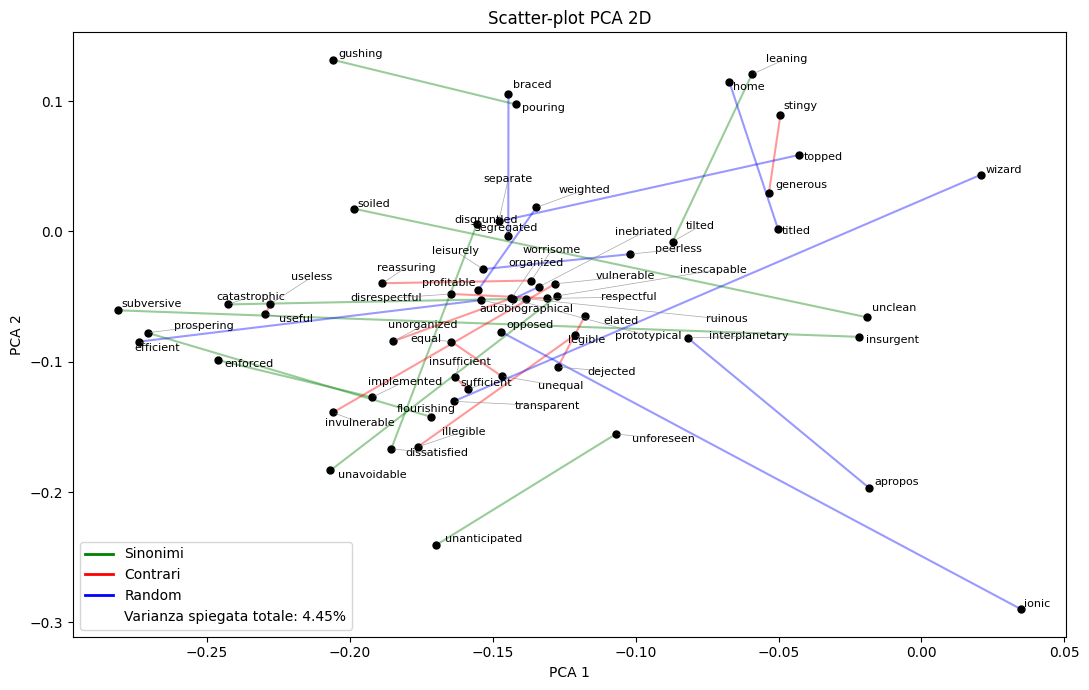

In [42]:
#scatter plot meno confusionario

colors = {
    "sinonimi": "green",
    "contrari": "red",
    "random": "blue"
}

word_to_xy = {
    word: pca_2_embedding[i]
    for i, word in enumerate(all_words)
}

varianza_totale = float(var_spiegata_2[:2].sum() * 100)

fig, ax = plt.subplots(figsize=(11, 7))

texts = []

for df, category in [
    (syn_df_2D, "sinonimi"),
    (ant_df_2D, "contrari"),
    (rand_df_2D, "random")
]:

    df_sample = df.sample(
        n=10,
        random_state=42
    )

    for _, row in df_sample.iterrows():

        if category == "sinonimi":
            word1 = row["word"]
            word2 = row["synonym"]

        elif category == "contrari":
            word1 = row["word"]
            word2 = row["antonym"]

        else:
            word1 = row["word"]
            word2 = row["random"]

        x1, y1 = word_to_xy[word1]
        x2, y2 = word_to_xy[word2]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colors[category],
            alpha=0.4,
            linewidth=1.5,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [y1, y2],
            color="black",
            s=25,
            zorder=2
        )

        texts.append(
            ax.text(
                x1,
                y1,
                word1,
                fontsize=8
            )
        )

        texts.append(
            ax.text(
                x2,
                y2,
                word2,
                fontsize=8
            )
        )

adjust_text(
    texts,
    ax=ax,
    force_text=1.5,
    force_points=1.0,
    expand_text=(1.5, 1.5),
    expand_points=(1.5, 1.5),
    expand_objects=(1.5, 1.5),
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.5,
        alpha=0.7
    )
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("Scatter-plot PCA 2D")

ax.legend(
    handles=[
        plt.Line2D(
            [0], [0],
            color="green",
            linewidth=2,
            label="Sinonimi"
        ),
        plt.Line2D(
            [0], [0],
            color="red",
            linewidth=2,
            label="Contrari"
        ),
        plt.Line2D(
            [0], [0],
            color="blue",
            linewidth=2,
            label="Random"
        ),
        plt.Line2D(
            [0], [0],
            color="none",
            label=f"Varianza spiegata totale: {varianza_totale:.2f}%"
        )
    ]
)

plt.tight_layout()

plt.savefig(
    "scatterplotPCA2D_semplificato.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

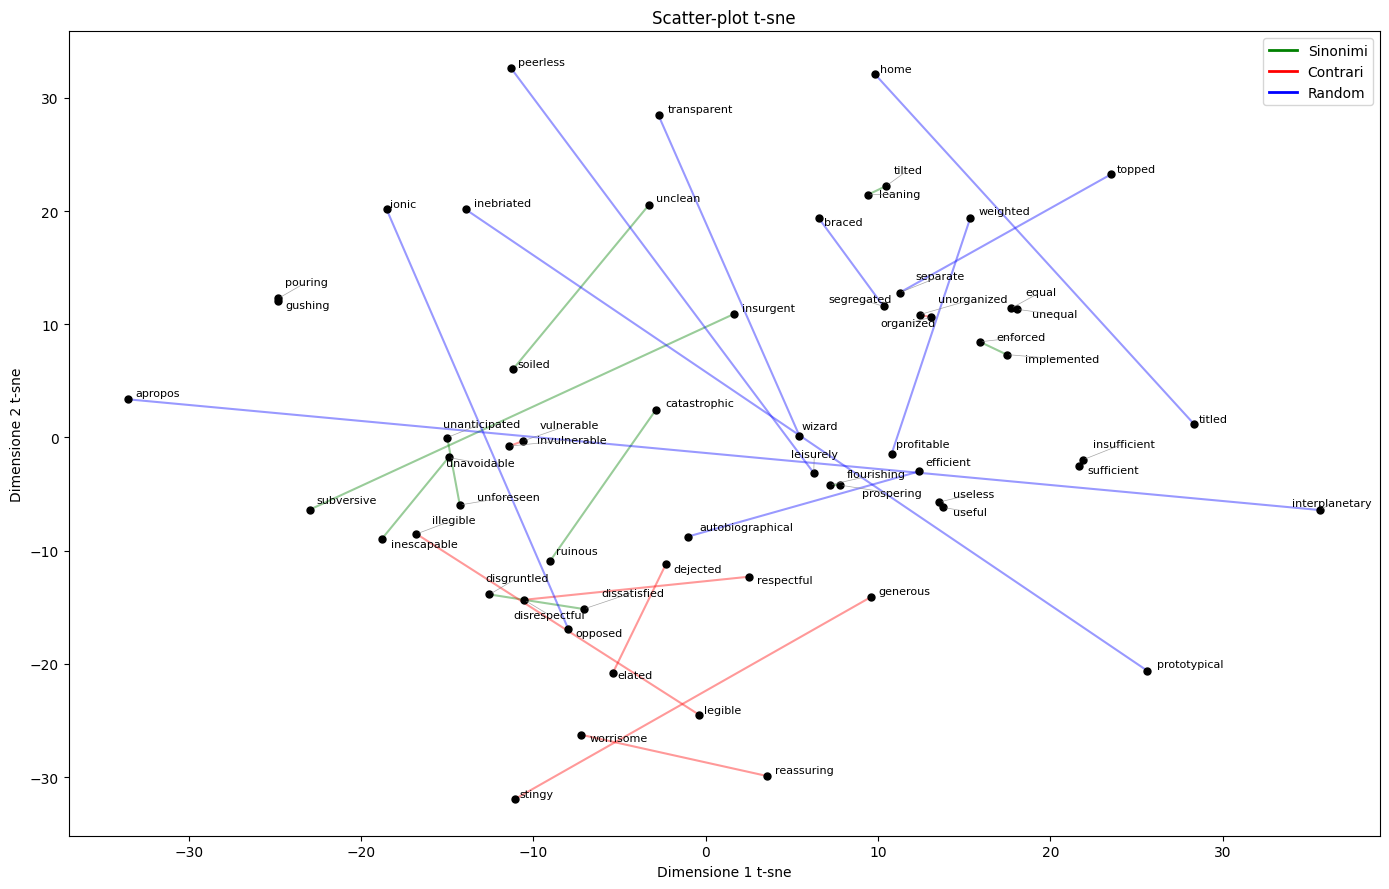

In [ ]:
#t-sne
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d_tsne = tsne.fit_transform(embedding_matrix_2)

# Plot

colors = {
    "sinonimi": "green",
    "contrari": "red",
    "random": "blue"
}

word_to_xy = {
    word: embeddings_2d_tsne[i]
    for i, word in enumerate(all_words)
}

fig, ax = plt.subplots(figsize=(14, 9))

texts = []

for df, category in [
    (syn_df_2D, "sinonimi"),
    (ant_df_2D, "contrari"),
    (rand_df_2D, "random")
]:

    df_sample = df.sample(
        n=10,
        random_state=42
    )

    for _, row in df_sample.iterrows():

        if category == "sinonimi":
            word1 = row["word"]
            word2 = row["synonym"]

        elif category == "contrari":
            word1 = row["word"]
            word2 = row["antonym"]

        else:
            word1 = row["word"]
            word2 = row["random"]

        x1, y1 = word_to_xy[word1]
        x2, y2 = word_to_xy[word2]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colors[category],
            alpha=0.4,
            linewidth=1.5,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [y1, y2],
            color="black",
            s=25,
            zorder=2
        )

        texts.append(
            ax.text(
                x1,
                y1,
                word1,
                fontsize=8
            )
        )

        texts.append(
            ax.text(
                x2,
                y2,
                word2,
                fontsize=8
            )
        )

adjust_text(
    texts,
    ax=ax,
    force_text=1.0,
    force_points=0.8,
    expand_text=(1.5, 1.5),
    expand_points=(1.5, 1.5),
    expand_objects=(1.5, 1.5),
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.5,
        alpha=0.7
    )
)

ax.set_xlabel("Dimensione 1 t-sne")
ax.set_ylabel("Dimensione 2 t-sne")
ax.set_title("Scatter-plot t-sne")

ax.legend(
    handles=[
        plt.Line2D(
            [0], [0],
            color="green",
            linewidth=2,
            label="Sinonimi"
        ),
        plt.Line2D(
            [0], [0],
            color="red",
            linewidth=2,
            label="Contrari"
        ),
        plt.Line2D(
            [0], [0],
            color="blue",
            linewidth=2,
            label="Random"
        )
    ]
)

plt.tight_layout()

plt.savefig(
    "scatterplot_t-sne2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


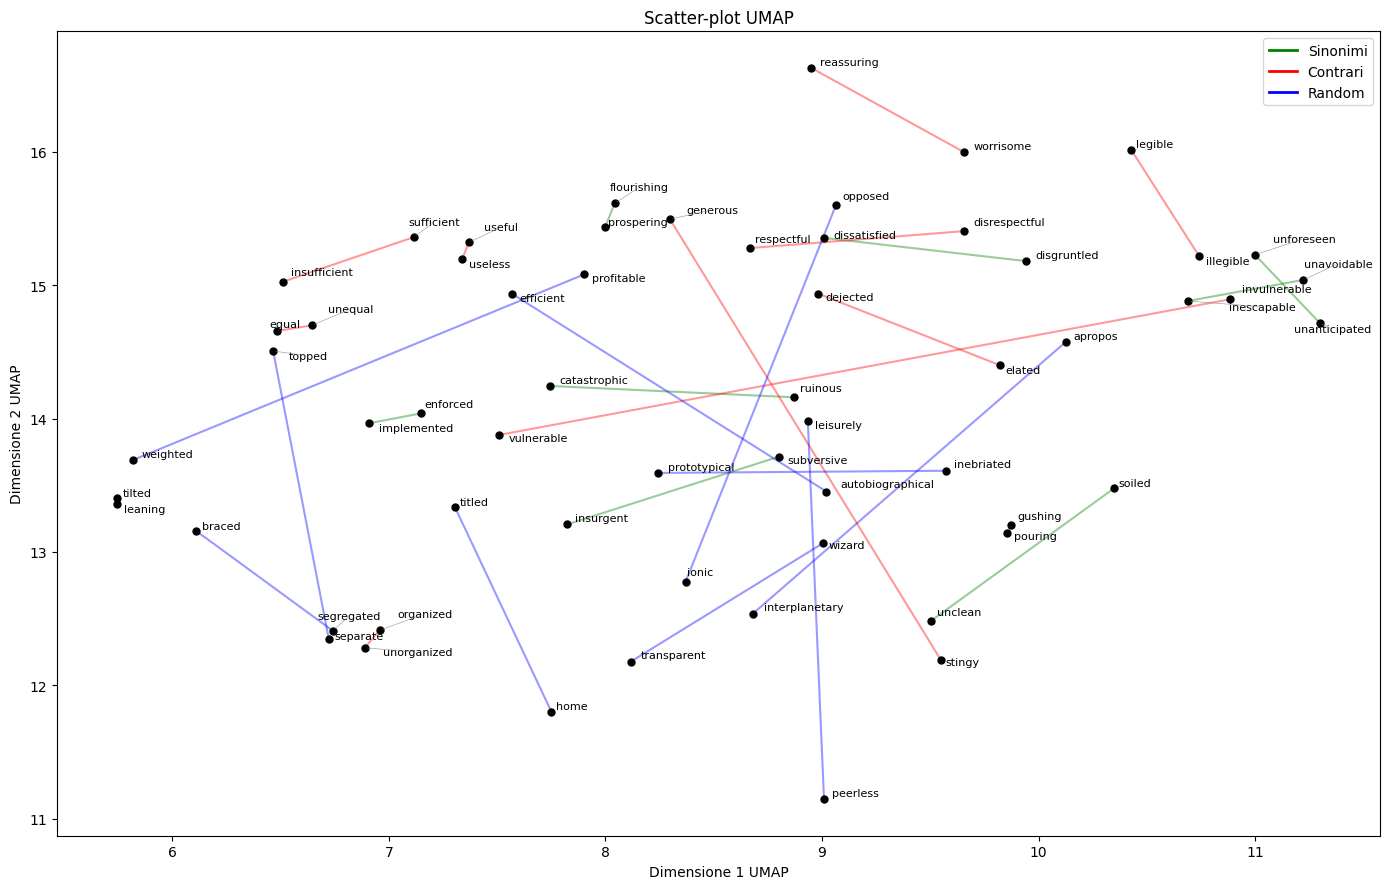

In [62]:
#UMAP 

umap = UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1    
)  #default

embeddings_2d_umap = umap.fit_transform(embedding_matrix_2)


# Plot

colors = {
    "sinonimi": "green",
    "contrari": "red",
    "random": "blue"
}

word_to_xy = {
    word: embeddings_2d_umap[i]
    for i, word in enumerate(all_words)
}

fig, ax = plt.subplots(figsize=(14, 9))

texts = []

for df, category in [
    (syn_df_2D, "sinonimi"),
    (ant_df_2D, "contrari"),
    (rand_df_2D, "random")
]:

    df_sample = df.sample(
        n=10,
        random_state=42
    )

    for _, row in df_sample.iterrows():

        if category == "sinonimi":
            word1 = row["word"]
            word2 = row["synonym"]

        elif category == "contrari":
            word1 = row["word"]
            word2 = row["antonym"]

        else:
            word1 = row["word"]
            word2 = row["random"]

        x1, y1 = word_to_xy[word1]
        x2, y2 = word_to_xy[word2]

        ax.plot(
            [x1, x2],
            [y1, y2],
            color=colors[category],
            alpha=0.4,
            linewidth=1.5,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [y1, y2],
            color="black",
            s=25,
            zorder=2
        )

        texts.append(
            ax.text(
                x1,
                y1,
                word1,
                fontsize=8
            )
        )

        texts.append(
            ax.text(
                x2,
                y2,
                word2,
                fontsize=8
            )
        )

adjust_text(
    texts,
    ax=ax,
    force_text=1.0,
    force_points=0.8,
    expand_text=(1.5, 1.5),
    expand_points=(1.5, 1.5),
    expand_objects=(1.5, 1.5),
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.5,
        alpha=0.7
    )
)

ax.set_xlabel("Dimensione 1 UMAP")
ax.set_ylabel("Dimensione 2 UMAP")
ax.set_title("Scatter-plot UMAP")

ax.legend(
    handles=[
        plt.Line2D(
            [0], [0],
            color="green",
            linewidth=2,
            label="Sinonimi"
        ),
        plt.Line2D(
            [0], [0],
            color="red",
            linewidth=2,
            label="Contrari"
        ),
        plt.Line2D(
            [0], [0],
            color="blue",
            linewidth=2,
            label="Random"
        )
    ]
)

plt.tight_layout()

plt.savefig(
    "scatterplot_UMAP2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
#guardare distribuzione di embedding originali centrati

media_embedding = embedding_matrix_2.mean(axis=0)

embedding_matrix_centrata = embedding_matrix_2 - media_embedding

In [68]:
#creo dizionario embedding centrati

diz_embeddings_centrati = {
    word: embedding_matrix_centrata[i]
    for i, word in enumerate(all_words)
}

In [70]:
#calcolo cosine similarity centrata per i dataset
syn_df_centrato = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_centrati
)

ant_df_centrato = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_centrati
)

rand_df_centrato = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_centrati
)

print("Sinonimi PCA 50 D:\n" ,syn_df_centrato.head() )
print("\n")
print("Sinonimi PCA 10 D:\n", ant_df_centrato.head())
print("\n")
print("Sinonimi PCA 2 D:\n",rand_df_centrato.head())


Sinonimi PCA 50 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.236734
1   ghastly      macabre  synonym           0.038018
2     dodgy        dicey  synonym           0.180701
3  biweekly  fortnightly  synonym           0.244374
4   pouring      gushing  synonym           0.415731


Sinonimi PCA 10 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.777262
1  centralized  decentralized  antonym           0.542107
2   reasonable   unreasonable  antonym           0.592235
3       simple        complex  antonym           0.232095
4      legible      illegible  antonym           0.217929


Sinonimi PCA 2 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random          -0.015748
1  unpalatable  melancholic   random           0.082879
2     obliging     definite   random          -0.071425
3    punishing  recombinant   random          -

In [71]:
#salvo i risultati
syn_df_centrato.to_csv(
    "results_synonyms_similarity_Centrato.csv",
    index=False
)

ant_df_centrato.to_csv(
    "results_antonyms_similarity_Centrato.csv",
    index=False
)

rand_df_centrato.to_csv(
    "results_random_similarity_Centrato.csv",
    index=False
)

In [72]:
#per caricare dataset
syn_df_centrato = pd.read_csv("results_synonyms_similarity_Centrato.csv")
ant_df_centrato = pd.read_csv("results_antonyms_similarity_Centrato.csv")
rand_df_centrato = pd.read_csv("results_random_similarity_Centrato.csv")

In [73]:
#statistiche descrittive
#Statistiche descrittive
print("SINONIMI")
print("Sinonimi per embedding centrati:\n")
print(syn_df_centrato["cosine_similarity"].describe().round(3))

print("\nCONTRARI")
print("Contrari per embedding centrati:\n")
print(ant_df_centrato["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 10 dimensioni:\n")

print("Random per embedding centrati:\n")
print(rand_df_centrato["cosine_similarity"].describe().round(3))


SINONIMI
Sinonimi per embedding centrati:

count    111.000
mean       0.243
std        0.197
min       -0.104
25%        0.084
50%        0.234
75%        0.368
max        0.765
Name: cosine_similarity, dtype: float64

CONTRARI
Contrari per embedding centrati:

count    111.000
mean       0.372
std        0.236
min       -0.092
25%        0.193
50%        0.389
75%        0.544
max        0.833
Name: cosine_similarity, dtype: float64
Contrari per embedding a 10 dimensioni:

Random per embedding centrati:

count    111.000
mean       0.006
std        0.085
min       -0.242
25%       -0.047
50%       -0.008
75%        0.045
max        0.236
Name: cosine_similarity, dtype: float64
